## Luyen tap 1

In [2]:
def T_dp(n):
    if n == 0 or n == 1:
        return 2
    
    # Tạo mảng lưu trữ giá trị từ T(0) đến T(n)
    dp = [0] * (n + 1)
    dp[0] = 2
    dp[1] = 2
    
    for current_n in range(2, n + 1):
        total_sum = 0
        for i in range(1, current_n):
            total_sum += 2 * dp[i] * dp[i-1]
        dp[current_n] = total_sum
        
    return dp[n]

# Thử nghiệm
for i in range(5):
    print(f"T({i}) = {T_dp(i)}")

T(0) = 2
T(1) = 2
T(2) = 8
T(3) = 40
T(4) = 680


## Luyen tap 2

In [3]:
def T_luyen_tap_2(n):
    if n == 0 or n == 1:
        return 2
    
    # Khởi tạo mảng lưu trữ kết quả các bài toán con
    dp = [0] * (n + 1)
    dp[0] = 2
    dp[1] = 2
    
    # Tính toán từ dưới lên
    for i in range(2, n + 1):
        tong_sum = 0
        for j in range(1, i):
            # T(i) = sum(2 * T(j) * T(j-1)) từ j=1 đến i-1
            tong_sum += 2 * dp[j] * dp[j-1]
        dp[i] = tong_sum
        
    return dp[n]

# Test thử
print(f"Luyện tập 2 - T(4): {T_luyen_tap_2(4)}")

Luyện tập 2 - T(4): 680


In [5]:
def giai_thich_luyen_tap_2(n):
    print(f"--- LUYỆN TẬP 2: QUY HOẠCH ĐỘNG (DP) ---")
    print("Vấn đề: Đệ quy thuần túy sẽ tính đi tính lại các giá trị cũ.")
    print("Giải pháp: Dùng mảng 'dp' để GHI NHỚ.\n")
    
    dp = [0] * (n + 1)
    dp[0] = dp[1] = 2
    print(f"Khởi tạo: T(0)=2, T(1)=2")
    
    for i in range(2, n + 1):
        print(f"\nĐang tính T({i}):")
        tong = 0
        for j in range(1, i):
            tich = 2 * dp[j] * dp[j-1]
            print(f"  + Lấy giá trị đã lưu: 2 * T({j}) * T({j-1}) = 2 * {dp[j]} * {dp[j-1]} = {tich}")
            tong += tich
        dp[i] = tong
        print(f"==> Lưu vào mảng: dp[{i}] = {dp[i]}")
    
    print(f"\nKẾT QUẢ: T({n}) = {dp[n]}")
    print("-" * 40)
giai_thich_luyen_tap_2(4)

--- LUYỆN TẬP 2: QUY HOẠCH ĐỘNG (DP) ---
Vấn đề: Đệ quy thuần túy sẽ tính đi tính lại các giá trị cũ.
Giải pháp: Dùng mảng 'dp' để GHI NHỚ.

Khởi tạo: T(0)=2, T(1)=2

Đang tính T(2):
  + Lấy giá trị đã lưu: 2 * T(1) * T(0) = 2 * 2 * 2 = 8
==> Lưu vào mảng: dp[2] = 8

Đang tính T(3):
  + Lấy giá trị đã lưu: 2 * T(1) * T(0) = 2 * 2 * 2 = 8
  + Lấy giá trị đã lưu: 2 * T(2) * T(1) = 2 * 8 * 2 = 32
==> Lưu vào mảng: dp[3] = 40

Đang tính T(4):
  + Lấy giá trị đã lưu: 2 * T(1) * T(0) = 2 * 2 * 2 = 8
  + Lấy giá trị đã lưu: 2 * T(2) * T(1) = 2 * 8 * 2 = 32
  + Lấy giá trị đã lưu: 2 * T(3) * T(2) = 2 * 40 * 8 = 640
==> Lưu vào mảng: dp[4] = 680

KẾT QUẢ: T(4) = 680
----------------------------------------


## Luyen tap 3

In [4]:
def T_luyen_tap_3(n):
    if n == 0 or n == 1:
        return 2
    if n == 2:
        return 8 # 2 * T(1) * T(0) = 2 * 2 * 2 = 8
    
    # t_minus_2 là T(i-2), t_minus_1 là T(i-1)
    t_minus_2 = 2 # T(1) cho bước tính T(3)
    t_minus_1 = 8 # T(2) cho bước tính T(3)
    
    current_t = 0
    for i in range(3, n + 1):
        # Sử dụng công thức rút gọn: T(n) = T(n-1) * (1 + 2 * T(n-2))
        current_t = t_minus_1 * (1 + 2 * t_minus_2)
        
        # Cập nhật biến cho vòng lặp kế tiếp
        t_minus_2 = t_minus_1
        t_minus_1 = current_t
        
    return current_t

# Test thử
print(f"Luyện tập 3 - T(4): {T_luyen_tap_3(4)}")

Luyện tập 3 - T(4): 680


In [6]:
def giai_thich_luyen_tap_3(n):
    print(f"\n--- LUYỆN TẬP 3: TỐI ƯU TOÁN HỌC ---")
    print("Vì sao cải thiện được? Vì T(n) có thể tính trực tiếp từ T(n-1) và T(n-2).")
    print("Công thức rút gọn: T(n) = T(n-1) * (1 + 2 * T(n-2))\n")
    
    if n < 2: return
    
    t_prev2 = 2 # T(0)
    t_prev1 = 2 # T(1)
    # T(2) = 2*T(1)*T(0) = 8
    curr = 8
    
    print(f"Bước khởi đầu: T(0)=2, T(1)=2, T(2)=8")
    
    for i in range(3, n + 1):
        # Tính toán siêu tốc không cần vòng lặp sum
        next_t = curr * (1 + 2 * t_prev1)
        print(f"Tính T({i}) nhanh: T({i-1}) * (1 + 2 * T({i-2}))")
        print(f"            = {curr} * (1 + 2 * {t_prev1}) = {next_t}")
        
        t_prev1 = curr
        curr = next_t

    print(f"\nKẾT QUẢ CUỐI CÙNG: T({n}) = {curr}")

giai_thich_luyen_tap_3(4)


--- LUYỆN TẬP 3: TỐI ƯU TOÁN HỌC ---
Vì sao cải thiện được? Vì T(n) có thể tính trực tiếp từ T(n-1) và T(n-2).
Công thức rút gọn: T(n) = T(n-1) * (1 + 2 * T(n-2))

Bước khởi đầu: T(0)=2, T(1)=2, T(2)=8
Tính T(3) nhanh: T(2) * (1 + 2 * T(1))
            = 8 * (1 + 2 * 2) = 40
Tính T(4) nhanh: T(3) * (1 + 2 * T(2))
            = 40 * (1 + 2 * 8) = 680

KẾT QUẢ CUỐI CÙNG: T(4) = 680


## Luyen tap 4

In [7]:
import sys
def max_subarray_kadane(arr):
    if not arr:
        return 0, -1, -1
    max_ending_here = arr[0]
    max_so_far = arr[0]
    start = end = s = 0
    for i in range(1, len(arr)):
        if arr[i] > max_ending_here + arr[i]:
            max_ending_here = arr[i]
            s = i
        else:
            max_ending_here += arr[i]
        if max_ending_here > max_so_far:
            max_so_far = max_ending_here
            start = s
            end = i
    return max_so_far, start, end

In [8]:
arr1 = [-2, 11, -4, 13, -5, 2]
arr2 = [1, -3, 4, -2, -1, 6]
tong1, i1, j1 = max_subarray_kadane(arr1)
tong2, i2, j2 = max_subarray_kadane(arr2)
print("Bài 4: Maximum Subarray (Kadane O(n))")
print(f"Mảng {arr1}: tổng lớn nhất = {tong1} (dãy con {arr1[i1:j1+1]})")
print(f"Mảng {arr2}: tổng lớn nhất = {tong2} (dãy con {arr2[i2:j2+1]})")
print()

Bài 4: Maximum Subarray (Kadane O(n))
Mảng [-2, 11, -4, 13, -5, 2]: tổng lớn nhất = 20 (dãy con [11, -4, 13])
Mảng [1, -3, 4, -2, -1, 6]: tổng lớn nhất = 7 (dãy con [4, -2, -1, 6])



## Luyen tap 5

In [9]:
print("Bài 5: Có thể cải thiện độ phức tạp hơn O(n)?")
print("Trả lời: Không thể. Để tính tổng dãy con lớn nhất, ta buộc phải duyệt qua")
print("tất cả n phần tử ít nhất một lần (lower bound Ω(n)). Mọi thuật toán")
print("đều cần đọc toàn bộ mảng, do đó O(n) là tối ưu.")
print()


Bài 5: Có thể cải thiện độ phức tạp hơn O(n)?
Trả lời: Không thể. Để tính tổng dãy con lớn nhất, ta buộc phải duyệt qua
tất cả n phần tử ít nhất một lần (lower bound Ω(n)). Mọi thuật toán
đều cần đọc toàn bộ mảng, do đó O(n) là tối ưu.



## Luyen tap 6

In [10]:
def max_subarray_dp_with_memory(arr):
    if not arr:
        return 0, -1, -1
    n = len(arr)
    dp = [0] * n
    dp[0] = arr[0]
    max_sum = dp[0]
    end_idx = 0
    start_idx = [0] * n  # lưu vị trí bắt đầu của dãy con kết thúc tại i
    start_idx[0] = 0
    for i in range(1, n):
        if dp[i-1] + arr[i] > arr[i]:
            dp[i] = dp[i-1] + arr[i]
            start_idx[i] = start_idx[i-1]
        else:
            dp[i] = arr[i]
            start_idx[i] = i
        if dp[i] > max_sum:
            max_sum = dp[i]
            end_idx = i
    return max_sum, start_idx[end_idx], end_idx

In [11]:
print("Bài 6: Quy hoạch động có cải thiện được độ phức tạp không?")
print("Cài đặt DP dùng mảng O(n) (có bộ nhớ):")
tong_dp, i_dp, j_dp = max_subarray_dp_with_memory(arr1)
print(f"Mảng {arr1}: tổng = {tong_dp} (dãy {arr1[i_dp:j_dp+1]})")
print("Trả lời: DP (có hoặc không bộ nhớ) đều đạt O(n) thời gian.")
print("Không thể cải thiện xuống dưới O(n) vì lý do chặn dưới Ω(n).")
print("DP chỉ giúp tối ưu từ O(n^2) xuống O(n), không thể thấp hơn.")
print()

Bài 6: Quy hoạch động có cải thiện được độ phức tạp không?
Cài đặt DP dùng mảng O(n) (có bộ nhớ):
Mảng [-2, 11, -4, 13, -5, 2]: tổng = 20 (dãy [11, -4, 13])
Trả lời: DP (có hoặc không bộ nhớ) đều đạt O(n) thời gian.
Không thể cải thiện xuống dưới O(n) vì lý do chặn dưới Ω(n).
DP chỉ giúp tối ưu từ O(n^2) xuống O(n), không thể thấp hơn.



## Luyen tap 7

In [12]:
def max_crossing_sum(arr, l, m, r):
    # Tổng lớn nhất bên trái điểm giữa (tính từ m về l)
    left_sum = -sys.maxsize
    total = 0
    for i in range(m, l-1, -1):
        total += arr[i]
        if total > left_sum:
            left_sum = total
    # Tổng lớn nhất bên phải điểm giữa (từ m+1 đến r)
    right_sum = -sys.maxsize
    total = 0
    for i in range(m+1, r+1):
        total += arr[i]
        if total > right_sum:
            right_sum = total
    return left_sum + right_sum

def max_subarray_divide_conquer(arr, l, r):
    if l == r:
        return arr[l]
    m = (l + r) // 2
    # Tốt nhất bên trái, bên phải hoặc vắt qua giữa
    return max(max_subarray_divide_conquer(arr, l, m),
               max_subarray_divide_conquer(arr, m+1, r),
               max_crossing_sum(arr, l, m, r))

In [13]:
print("Bài 7: Các cách khác để giải Maximum Subarray")
print("1. DP không bộ nhớ (Kadane) - đã dùng ở bài 4.")
# Gọi lại Kadane để minh hoạ
tong_kadane, _, _ = max_subarray_kadane(arr1)
print(f"   Kadane: mảng {arr1} -> {tong_kadane}")
print("2. Chia để trị (Divide & Conquer) O(n log n):")
tong_dc = max_subarray_divide_conquer(arr1, 0, len(arr1)-1)
print(f"   Chia để trị: mảng {arr1} -> {tong_dc}")
print("Cả hai cách đều trả về cùng kết quả. Kadane (DP không bộ nhớ) tối ưu nhất.")

Bài 7: Các cách khác để giải Maximum Subarray
1. DP không bộ nhớ (Kadane) - đã dùng ở bài 4.
   Kadane: mảng [-2, 11, -4, 13, -5, 2] -> 20
2. Chia để trị (Divide & Conquer) O(n log n):
   Chia để trị: mảng [-2, 11, -4, 13, -5, 2] -> 20
Cả hai cách đều trả về cùng kết quả. Kadane (DP không bộ nhớ) tối ưu nhất.


# Bai tap

## Bai tap 1

In [21]:
import sys
import time
import random
from bisect import bisect_right
import matplotlib.pyplot as plt

In [22]:
# ============================================================
# Bài 1: Đếm số tổ hợp C(n, k) sử dụng quy hoạch động (tam giác Pascal)
# ============================================================
def combination_dp(n, k):
    if k < 0 or k > n:
        return 0
    # Khởi tạo bảng 2 chiều (n+1)x(k+1) để tiết kiệm bộ nhớ
    C = [[0] * (k + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        for j in range(min(i, k) + 1):
            if j == 0 or j == i:
                C[i][j] = 1
            else:
                C[i][j] = C[i - 1][j - 1] + C[i - 1][j]
    return C[n][k]

In [23]:
# ============================================================
# Bài 2: Dãy con đơn điệu tăng dài nhất (LIS) - O(n^2)
# Trả về (độ dài, dãy con)
# ============================================================
def longest_increasing_subsequence(a):
    n = len(a)
    if n == 0:
        return 0, []
    dp = [1] * n
    trace = [-1] * n  # lưu chỉ số phần tử đứng trước trong LIS
    max_len = 0
    last_idx = 0
    for i in range(n):
        for j in range(i):
            if a[j] < a[i] and dp[j] + 1 > dp[i]:
                dp[i] = dp[j] + 1
                trace[i] = j
        if dp[i] > max_len:
            max_len = dp[i]
            last_idx = i
    # Truy vét
    lis = []
    idx = last_idx
    while idx != -1:
        lis.append(a[idx])
        idx = trace[idx]
    lis.reverse()
    return max_len, lis

In [24]:
# ============================================================
# Bài 3: Bài toán cái túi 0-1 Knapsack
# Trả về (giá trị lớn nhất, danh sách các chỉ số món đồ được chọn)
# ============================================================
def knapsack_01(weights, values, capacity):
    n = len(weights)
    # Bảng DP có kích thước (n+1) x (capacity+1)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                dp[i][w] = max(dp[i - 1][w],
                               dp[i - 1][w - weights[i - 1]] + values[i - 1])
            else:
                dp[i][w] = dp[i - 1][w]

    # Truy vét các món được chọn
    res_value = dp[n][capacity]
    w = capacity
    chosen = []
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i - 1][w]:
            chosen.append(i - 1)  # lưu chỉ số (bắt đầu từ 0)
            w -= weights[i - 1]
    chosen.reverse()
    return res_value, chosen

In [25]:
# ============================================================
# Bài 4: Xâu con chung dài nhất (LCS)
# Trả về (độ dài, xâu LCS)
# ============================================================
def longest_common_subsequence(X, Y):
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i - 1] == Y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    # Truy vét xâu LCS
    i, j = m, n
    lcs = []
    while i > 0 and j > 0:
        if X[i - 1] == Y[j - 1]:
            lcs.append(X[i - 1])
            i -= 1
            j -= 1
        elif dp[i - 1][j] > dp[i][j - 1]:
            i -= 1
        else:
            j -= 1
    lcs.reverse()
    return dp[m][n], ''.join(lcs)

In [26]:
# ============================================================
# Bài 5: Bố trí phòng họp (Interval Scheduling)
# Tối đa số cuộc họp không giao nhau (chọn theo thời gian kết thúc sớm nhất)
# Trả về (số cuộc họp tối đa, danh sách chỉ số cuộc họp được chọn)
# ============================================================
def max_meetings(start, finish):
    n = len(start)
    meetings = [(start[i], finish[i], i) for i in range(n)]
    # Sắp xếp tăng dần theo finish time
    meetings.sort(key=lambda x: x[1])
    selected = []
    last_finish = -1
    for s, f, idx in meetings:
        if s >= last_finish:
            selected.append(idx)
            last_finish = f
    return len(selected), selected


In [27]:
# ============================================================
# Bài 6: Cho thuê máy (Weighted Interval Scheduling)
# Mỗi khách i: thuê [a_i, b_i) hoặc [a_i, b_i] với giá c_i.
# Yêu cầu tổng tiền lớn nhất, các khoảng không giao nhau.
# Giả sử đầu vào: mảng a, b, c (thời gian kết thúc b_i, có thể chọn khách có b_i <= a_j)
# Sử dụng quy hoạch động O(n^2).
# Trả về (tổng tiền lớn nhất, danh sách công việc được chọn)
# ============================================================
def weighted_interval_scheduling(a, b, c):
    n = len(a)
    # Tạo danh sách công việc
    jobs = [(a[i], b[i], c[i], i) for i in range(n)]
    # Sắp xếp theo thời gian kết thúc tăng dần
    jobs.sort(key=lambda x: x[1])
    # DP[i] là tổng tiền lớn nhất khi xét tới công việc thứ i (theo thứ tự đã sắp)
    dp = [0] * n
    # chọn[i] lưu chỉ số công việc liền trước trong phương án tối ưu, hoặc -1 nếu không chọn
    prev = [-1] * n
    # selected[i] cho biết có chọn công việc i không
    is_chosen = [False] * n

    for i in range(n):
        # Nếu chỉ chọn mình công việc i
        dp[i] = jobs[i][2]
        prev[i] = -1
        # Tìm công việc j không giao nhau và kết thúc trước i
        for j in range(i):
            if jobs[j][1] <= jobs[i][0]:  # kết thúc của j <= bắt đầu của i
                if dp[j] + jobs[i][2] > dp[i]:
                    dp[i] = dp[j] + jobs[i][2]
                    prev[i] = j

    # Tìm chỉ số của công việc cuối cùng cho tổng lớn nhất
    max_val = -1
    best_idx = 0
    for i in range(n):
        if dp[i] > max_val:
            max_val = dp[i]
            best_idx = i

    # Truy vét
    chosen = []
    idx = best_idx
    while idx != -1:
        chosen.append(jobs[idx][3])  # chỉ số gốc
        idx = prev[idx]
    chosen.reverse()
    return max_val, chosen


In [28]:
# ==================== Bài 7: Xếp các khối đá ====================
def max_blocks(blocks):
    """
    blocks: list of tuple (dai, rong, cao)
    Trả về số lượng khối tối đa có thể chồng lên nhau.
    """
    processed = []
    for x, y, z in blocks:
        dims = [x, y, z]
        h = min(dims)
        # Hai cạnh còn lại
        dims.remove(h)
        a = max(dims)
        b = min(dims)
        processed.append((a, b))
    # Sắp xếp giảm dần theo a, rồi giảm dần theo b
    processed.sort(key=lambda t: (-t[0], -t[1]))
    # Tìm dãy con không tăng dài nhất trên b (dùng LIS trên -b)
    tails = []
    for a, b in processed:
        val = -b  # đảo dấu để tìm dãy không giảm
        idx = bisect_right(tails, val)
        if idx == len(tails):
            tails.append(val)
        else:
            tails[idx] = val
    return len(tails)

In [29]:
# ==================== Bài 8: Farmer (IOI 2004) ====================
def max_olive_trees(fields, strips, Q):
    """
    fields: list of B_j (số cây bách trên mảnh đất)
    strips: list of A_i (số cây bách trên dải đất)
    Q: giới hạn tổng số cây bách
    Trả về tổng số cây ôliu lớn nhất.
    """
    items = []
    for a in strips:
        items.append((a, a - 1))  # (weight, value)
    for b in fields:
        items.append((b, b - 1))
    # 0-1 knapsack với capacity Q
    dp = [0] * (Q + 1)
    for weight, value in items:
        for c in range(Q, weight - 1, -1):
            if dp[c - weight] + value > dp[c]:
                dp[c] = dp[c - weight] + value
    return dp[Q]

Chạy đánh giá thời gian cho các bài toán...
Bai 1 (To hop) ['0.000010', '0.000018', '0.000024', '0.000111', '0.000400', '0.001724', '0.015725', '0.066318']
Bai 2 (LIS O(n^2)) ['0.000005', '0.000011', '0.000017', '0.000071', '0.000252', '0.000858', '0.005820', '0.027135']
Bai 3 (Knapsack) ['0.000949', '0.002946', '0.004724', '0.010600', '0.018528', '0.042375', '0.101343', '0.210062']
Bai 4 (LCS) ['0.000015', '0.000026', '0.000085', '0.000384', '0.001509', '0.010161', '0.042596', 'N/A']
Bai 5 (Meetings) ['0.000006', '0.000006', '0.000009', '0.000015', '0.000023', '0.000057', '0.000100', '0.000429']
Bai 6 (Weighted Interval) ['0.000013', '0.000014', '0.000034', '0.000151', '0.000521', '0.001886', '0.010760', '0.043544']
Bai 7 (Xep da) ['0.000012', '0.000014', '0.000018', '0.000038', '0.000070', '0.000145', '0.000596', '0.000716']
Bai 8 (Farmer) ['0.001798', '0.003647', '0.008737', '0.019877', '0.038739', '0.068427', '0.144100']


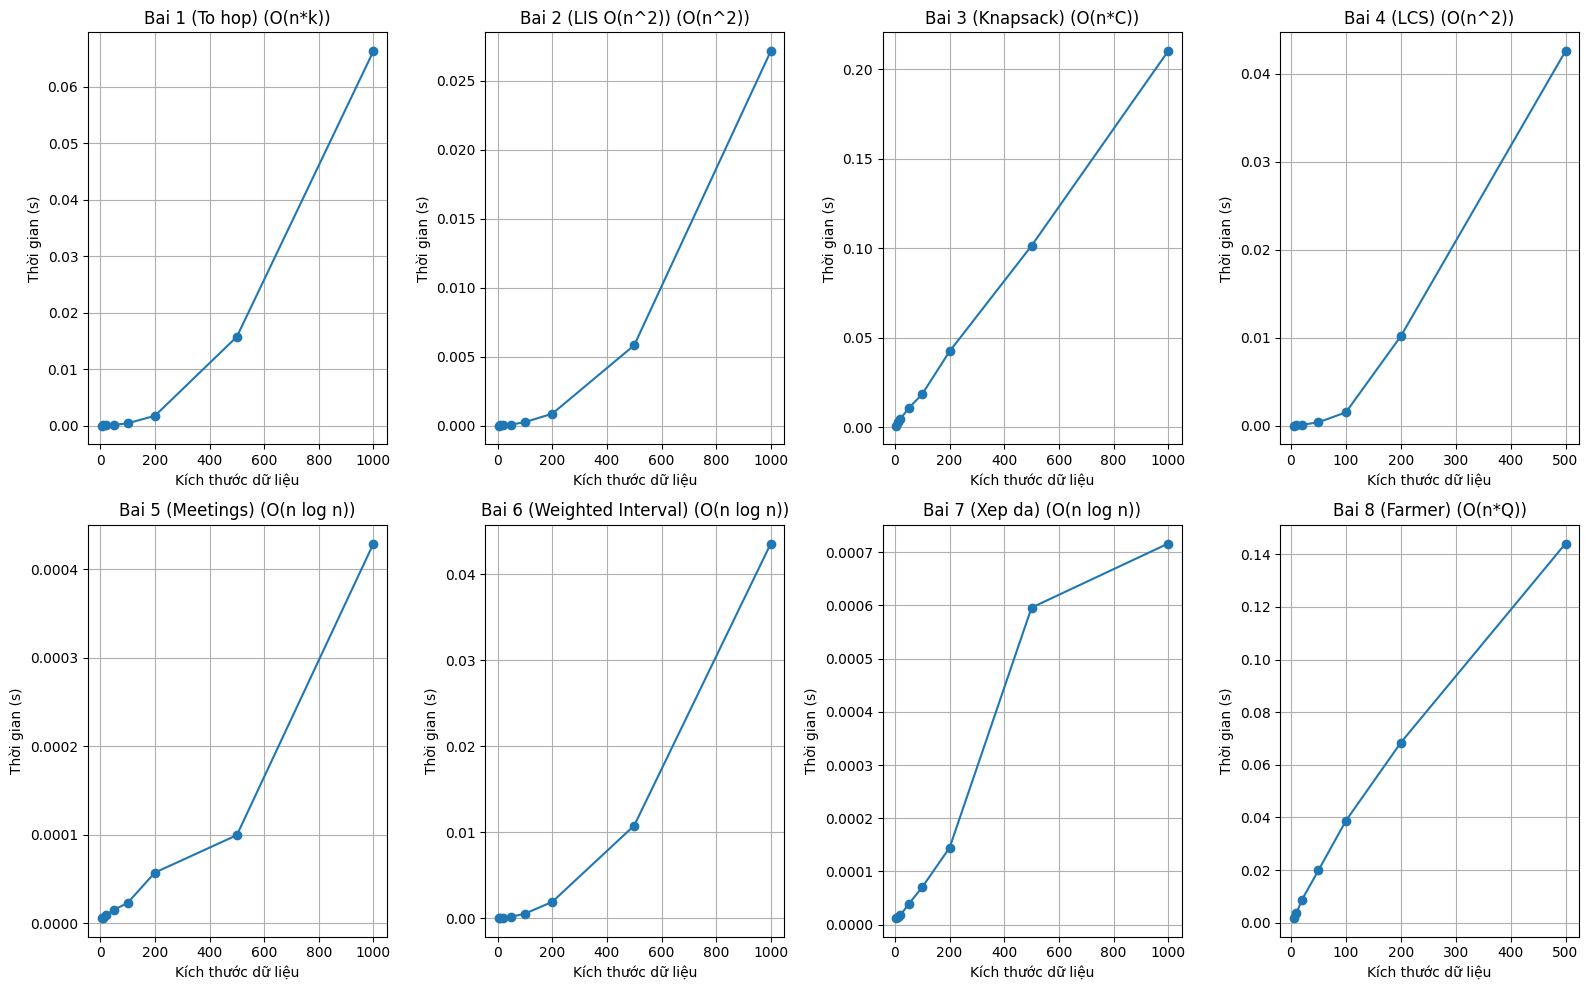

In [30]:
# ==================== HÀM KIỂM TRA & VẼ BIỂU ĐỒ ====================
def measure_time(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return end - start, result

def generate_test_data():
    """Tạo dữ liệu test cho từng bài toán và lưu lại thời gian chạy."""
    sizes = [5, 10, 20, 50, 100, 200, 500, 1000]  # các kích thước đầu vào chính
    # Một số bài cần điều chỉnh để tránh quá tải
    times = {
        'Bai 1 (To hop)': [],
        'Bai 2 (LIS O(n^2))': [],
        'Bai 3 (Knapsack)': [],
        'Bai 4 (LCS)': [],
        'Bai 5 (Meetings)': [],
        'Bai 6 (Weighted Interval)': [],
        'Bai 7 (Xep da)': [],
        'Bai 8 (Farmer)': []
    }
    sizes_8 = [5, 10, 20, 50, 100, 200, 500]  # Q tối đa 5000, n nhỏ hơn
    for n in sizes:
        # Bài 1
        t, _ = measure_time(combination_dp, n, n//2)
        times['Bai 1 (To hop)'].append(t)

        # Bài 2: LIS O(n^2)
        arr = [random.randint(1, 1000) for _ in range(n)]
        t, _ = measure_time(longest_increasing_subsequence, arr)
        times['Bai 2 (LIS O(n^2))'].append(t)

        # Bài 3: Knapsack với capacity = 1000, số lượng item = n
        if n <= 1000:
            weights = [random.randint(1, 50) for _ in range(n)]
            values = [random.randint(1, 100) for _ in range(n)]
            cap = 1000
            t, _ = measure_time(knapsack_01, weights, values, cap)
            times['Bai 3 (Knapsack)'].append(t)
        else:
            times['Bai 3 (Knapsack)'].append(None)

        # Bài 4: LCS với độ dài xâu n
        if n <= 500:
            X = ''.join(random.choices('ABCDEFGH', k=n))
            Y = ''.join(random.choices('ABCDEFGH', k=n))
            t, _ = measure_time(longest_common_subsequence, X, Y)
            times['Bai 4 (LCS)'].append(t)
        else:
            times['Bai 4 (LCS)'].append(None)

        # Bài 5: n cuộc họp
        start = [random.randint(0, 1000) for _ in range(n)]
        finish = [s + random.randint(1, 100) for s in start]
        t, _ = measure_time(max_meetings, start, finish)
        times['Bai 5 (Meetings)'].append(t)

        # Bài 6: Weighted Interval Scheduling (O(n log n))
        a = [random.randint(0, 1000) for _ in range(n)]
        b = [ai + random.randint(1, 100) for ai in a]
        c = [random.randint(1, 100) for _ in range(n)]
        t, _ = measure_time(weighted_interval_scheduling, a, b, c)
        times['Bai 6 (Weighted Interval)'].append(t)

        # Bài 7: Xếp đá (O(n log n))
        blocks = [(random.randint(1, 100), random.randint(1, 100), random.randint(1, 100)) for _ in range(n)]
        t, _ = measure_time(max_blocks, blocks)
        times['Bai 7 (Xep da)'].append(t)

    # Bài 8: Farmer với n items, Q = 5000
    for n in sizes_8:
        strips = [random.randint(2, 50) for _ in range(n//2)]
        fields = [random.randint(2, 50) for _ in range(n - n//2)]
        Q = 5000
        t, _ = measure_time(max_olive_trees, fields, strips, Q)
        times['Bai 8 (Farmer)'].append(t)

    return sizes, sizes_8, times

# ==================== CHẠY ĐÁNH GIÁ ====================
if __name__ == "__main__":
    print("Chạy đánh giá thời gian cho các bài toán...")
    sizes, sizes_8, times = generate_test_data()

    # In kết quả thời gian (tham khảo)
    for k, v in times.items():
        print(k, [f"{x:.6f}" if x is not None else "N/A" for x in v])

    # Vẽ biểu đồ
    fig, axes = plt.subplots(2, 4, figsize=(16, 10))
    axes = axes.flatten()
    plot_info = [
        ('Bai 1 (To hop)', sizes, times['Bai 1 (To hop)'], 'O(n*k)'),
        ('Bai 2 (LIS O(n^2))', sizes, times['Bai 2 (LIS O(n^2))'], 'O(n^2)'),
        ('Bai 3 (Knapsack)', sizes[:len(times['Bai 3 (Knapsack)']) if None not in times['Bai 3 (Knapsack)'] else -1], 
         [t for t in times['Bai 3 (Knapsack)'] if t is not None], 'O(n*C)'),
        ('Bai 4 (LCS)', [s for s, t in zip(sizes, times['Bai 4 (LCS)']) if t is not None],
         [t for t in times['Bai 4 (LCS)'] if t is not None], 'O(n^2)'),
        ('Bai 5 (Meetings)', sizes, times['Bai 5 (Meetings)'], 'O(n log n)'),
        ('Bai 6 (Weighted Interval)', sizes, times['Bai 6 (Weighted Interval)'], 'O(n log n)'),
        ('Bai 7 (Xep da)', sizes, times['Bai 7 (Xep da)'], 'O(n log n)'),
        ('Bai 8 (Farmer)', sizes_8, times['Bai 8 (Farmer)'], 'O(n*Q)')
    ]

    for ax, (title, x, y, complexity) in zip(axes, plot_info):
        ax.plot(x, y, marker='o')
        ax.set_title(f"{title} ({complexity})")
        ax.set_xlabel("Kích thước dữ liệu")
        ax.set_ylabel("Thời gian (s)")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

## Bai tap 2

In [14]:
def longest_common_subsequence(X, Y):
    m, n = len(X), len(Y)
    # Khởi tạo bảng DP với các giá trị 0
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i-1] == Y[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
                
    return dp[m][n]

# Test
X = "ABCBDAB"
Y = "BDCAB"
print(f"Bài 1 - LCS: {longest_common_subsequence(X, Y)}") # Output: 4 (BDAB)

Bài 1 - LCS: 4


In [15]:
def min_insertions_palindrome(S):
    n = len(S)
    S_rev = S[::-1] # Xâu đảo ngược
    
    # Sử dụng lại logic của bài LCS
    dp = [[0] * (n + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if S[i-1] == S_rev[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
                
    lps_length = dp[n][n]
    return n - lps_length

# Test
S = "mbadm"
print(f"Bài 2 - Số phép thêm: {min_insertions_palindrome(S)}") # Output: 2 (thêm 'm', 'b' -> mbadabm)

Bài 2 - Số phép thêm: 2


In [16]:
def max_bridges(M, N, relations):
    # Khởi tạo ma trận quan hệ
    C = [[0] * (N + 1) for _ in range(M + 1)]
    for u, v in relations:
        C[u][v] = 1
        
    # Quy hoạch động giống hệt biến thể LCS
    dp = [[0] * (N + 1) for _ in range(M + 1)]
    
    for i in range(1, M + 1):
        for j in range(1, N + 1):
            # Không nối i và j
            dp[i][j] = max(dp[i-1][j], dp[i][j-1])
            # Nếu có thể nối i và j (chắc chắn không cắt vì ta lấy kết quả từ i-1, j-1)
            if C[i][j] == 1:
                dp[i][j] = max(dp[i][j], dp[i-1][j-1] + 1)
                
    return dp[M][N]

# Test: Bắc có 4, Nam có 5. Quan hệ: (1,2), (1,3), (2,4), (3,1), (4,5)
relations = [(1,2), (1,3), (2,4), (3,1), (4,5)]
print(f"Bài 3 - Số cầu tối đa: {max_bridges(4, 5, relations)}") # Output: 3 (Nối 1-2, 2-4, 4-5)

Bài 3 - Số cầu tối đa: 3


In [17]:
def max_product_of_subsets(A):
    total_sum = sum(A)
    target = total_sum // 2
    
    # dp[j] = True nếu có thể tạo ra tổng j
    dp = [False] * (target + 1)
    dp[0] = True
    
    # Subset Sum DP
    for num in A:
        for j in range(target, num - 1, -1):
            if dp[j - num]:
                dp[j] = True
                
    # Tìm tổng S1 gần target nhất
    s1 = 0
    for j in range(target, -1, -1):
        if dp[j]:
            s1 = j
            break
            
    s2 = total_sum - s1
    return s1 * s2

# Test
A = [1, 2, 3, 4, 5] # Tổng = 15. Gần giữa nhất là 7 và 8. Tích = 56
print(f"Bài 4 - Tích cực đại: {max_product_of_subsets(A)}")

Bài 4 - Tích cực đại: 56
